# Business Sales Performance Analytics

**Task 1**

This notebook provides a comprehensive analysis of business sales data to uncover key insights into revenue trends, top-performing products, high-value customer segments, and regional sales performance. The goal is to generate actionable recommendations for strategic business decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv to online_retail.csv


In [ ]:
df=pd.read_csv('online_retail.csv')

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
## Checking for missing values in the DataFrame
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df.dropna(subset=['Description', 'CustomerID'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [8]:
## Checking if we've dealt with all the missing values from the Description column
missing_description_values = df['Description'].isnull().sum()
print(f"Number of missing values in 'Description' column: {missing_description_values}")

Number of missing values in 'Description' column: 0


In [9]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 5225


In [10]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


In [11]:
df.duplicated().sum()

np.int64(0)

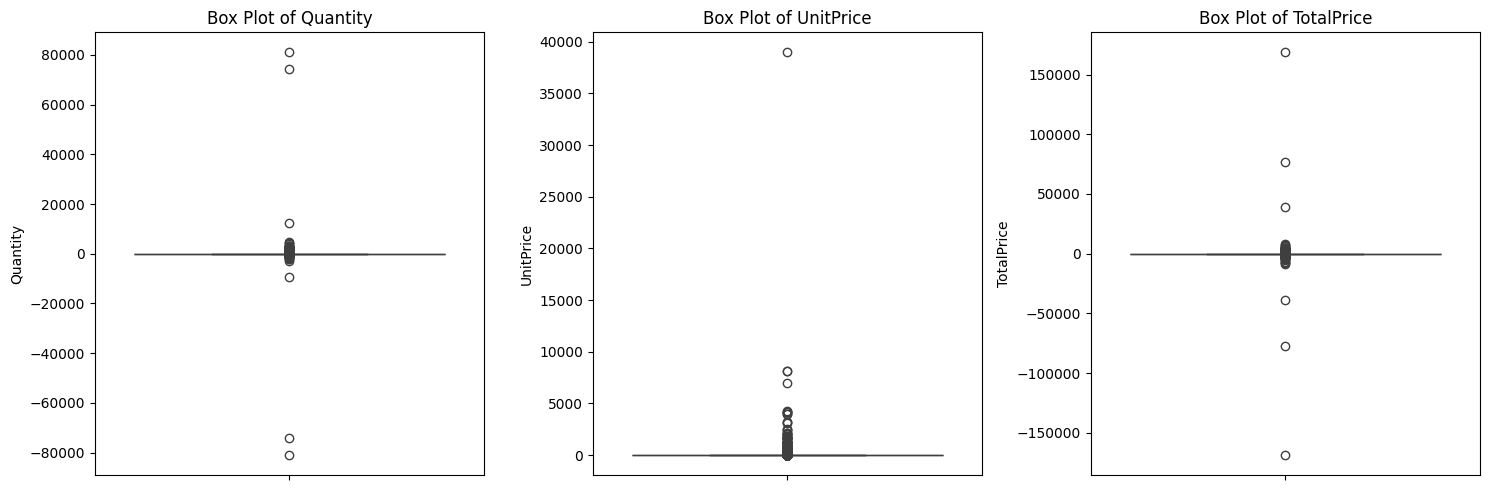

Descriptive statistics for numerical columns to identify extreme values:


,Quantity,UnitPrice,TotalPrice
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,20.613638
std,250.283037,69.764035,430.352218
min,-80995.000000,0.000000,-168469.600000
1%,-2.000000,0.210000,-9.900000
5%,1.000000,0.420000,0.850000
25%,2.000000,1.250000,4.250000
50%,5.000000,1.950000,11.700000
75%,12.000000,3.750000,19.800000
95%,36.000000,8.500000,67.500000


In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
numerical_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

print("Descriptive statistics for numerical columns to identify extreme values:")
display(df[numerical_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

In [15]:
## Handling all the outliers in the data and that we have seen from data visualisation plots (1 of 2)
def remove_outliers(col):
    d25=df[col].quantile(0.25)
    d75=df[col].quantile(0.75)
    diqr=d75-d25
    upper_lim=d75+1.5*diqr
    lower_lim=d25-1.5*diqr
    filter_df=df[ (df[col] >= lower_lim) & (df[col] <= upper_lim) ]
    return filter_df

df=remove_outliers('UnitPrice')
df=remove_outliers('Quantity')
df=remove_outliers('TotalPrice')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312582 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    312582 non-null  object        
 1   StockCode    312582 non-null  object        
 2   Description  312582 non-null  object        
 3   Quantity     312582 non-null  int64         
 4   InvoiceDate  312582 non-null  datetime64[ns]
 5   UnitPrice    312582 non-null  float64       
 6   CustomerID   312582 non-null  float64       
 7   Country      312582 non-null  object        
 8   TotalPrice   312582 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 23.8+ MB


In [17]:
## Handling all the outliers in the data and that we have seen from data visualisation plots (2 of 2)
def remove_outliers(col):
    d25=df[col].quantile(0.25)
    d75=df[col].quantile(0.75)
    diqr=d75-d25
    upper_lim=d75+1.5*diqr
    lower_lim=d25-1.5*diqr
    filter_df=df[ (df[col] >= lower_lim) & (df[col] <= upper_lim) ]
    return filter_df

df=remove_outliers('UnitPrice')
df=remove_outliers('Quantity')
df=remove_outliers('TotalPrice')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312582 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    312582 non-null  object        
 1   StockCode    312582 non-null  object        
 2   Description  312582 non-null  object        
 3   Quantity     312582 non-null  int64         
 4   InvoiceDate  312582 non-null  datetime64[ns]
 5   UnitPrice    312582 non-null  float64       
 6   CustomerID   312582 non-null  float64       
 7   Country      312582 non-null  object        
 8   TotalPrice   312582 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 23.8+ MB


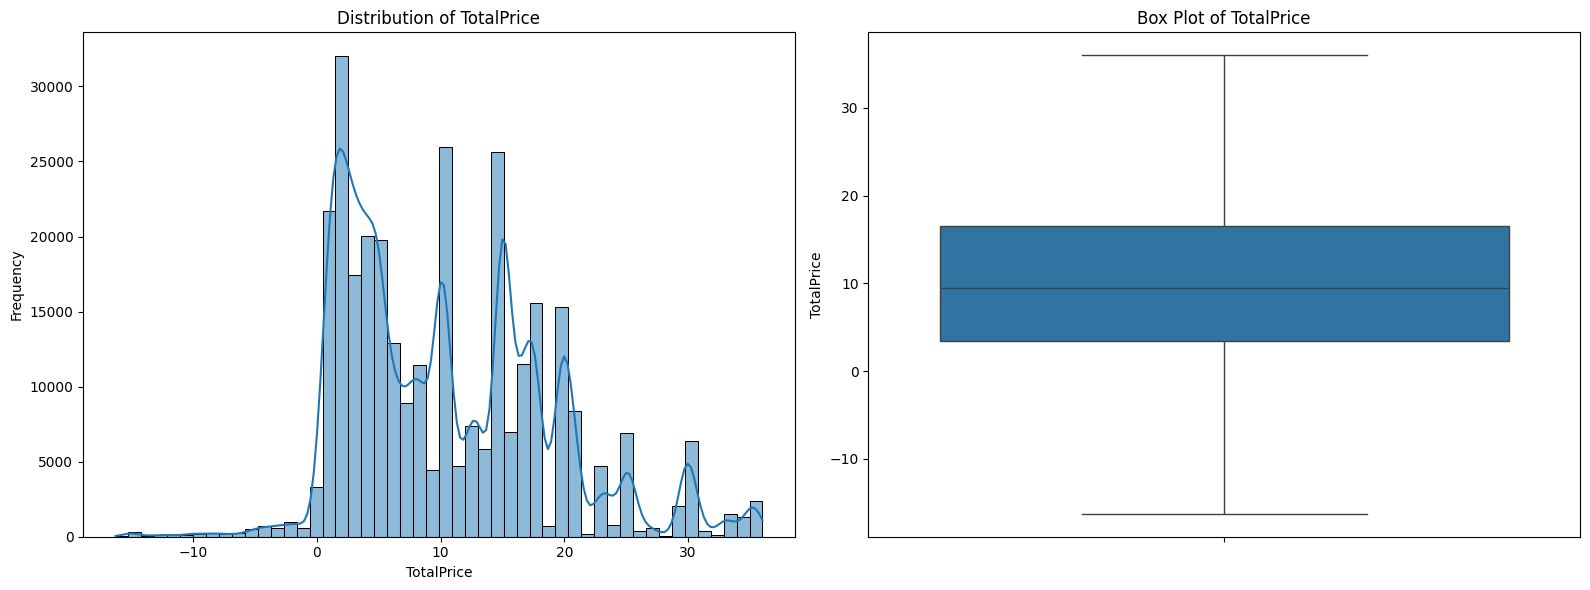

In [18]:
## Create a figure with two subplots for histogram and box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## Histogram for TotalPrice
sns.histplot(df['TotalPrice'], kde=True, ax=axes[0], bins=50)
axes[0].set_title('Distribution of TotalPrice')
axes[0].set_xlabel('TotalPrice')
axes[0].set_ylabel('Frequency')

## Box plot for TotalPrice
sns.boxplot(y=df['TotalPrice'], ax=axes[1])
axes[1].set_title('Box Plot of TotalPrice')
axes[1].set_ylabel('TotalPrice')

plt.tight_layout()
plt.show()

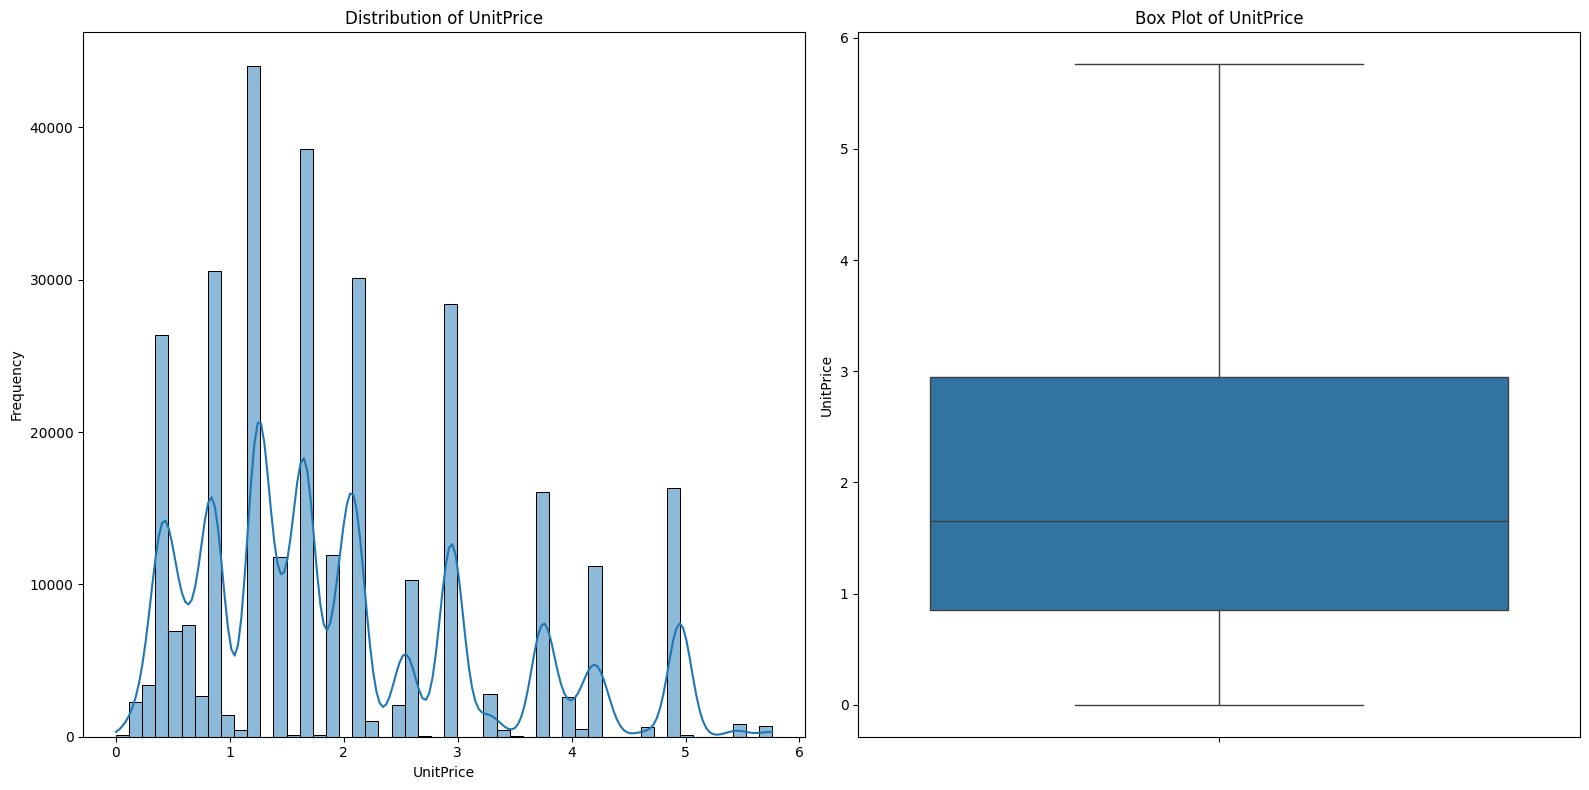

In [19]:
## Create a figure with two subplots for histogram and box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

## Histogram for UnitPrice
sns.histplot(df['UnitPrice'], kde=True, ax=axes[0], bins=50)
axes[0].set_title('Distribution of UnitPrice')
axes[0].set_xlabel('UnitPrice')
axes[0].set_ylabel('Frequency')

## Box plot for UnitPrice
sns.boxplot(y=df['UnitPrice'], ax=axes[1])
axes[1].set_title('Box Plot of UnitPrice')
axes[1].set_ylabel('UnitPrice')

plt.tight_layout()
plt.show()

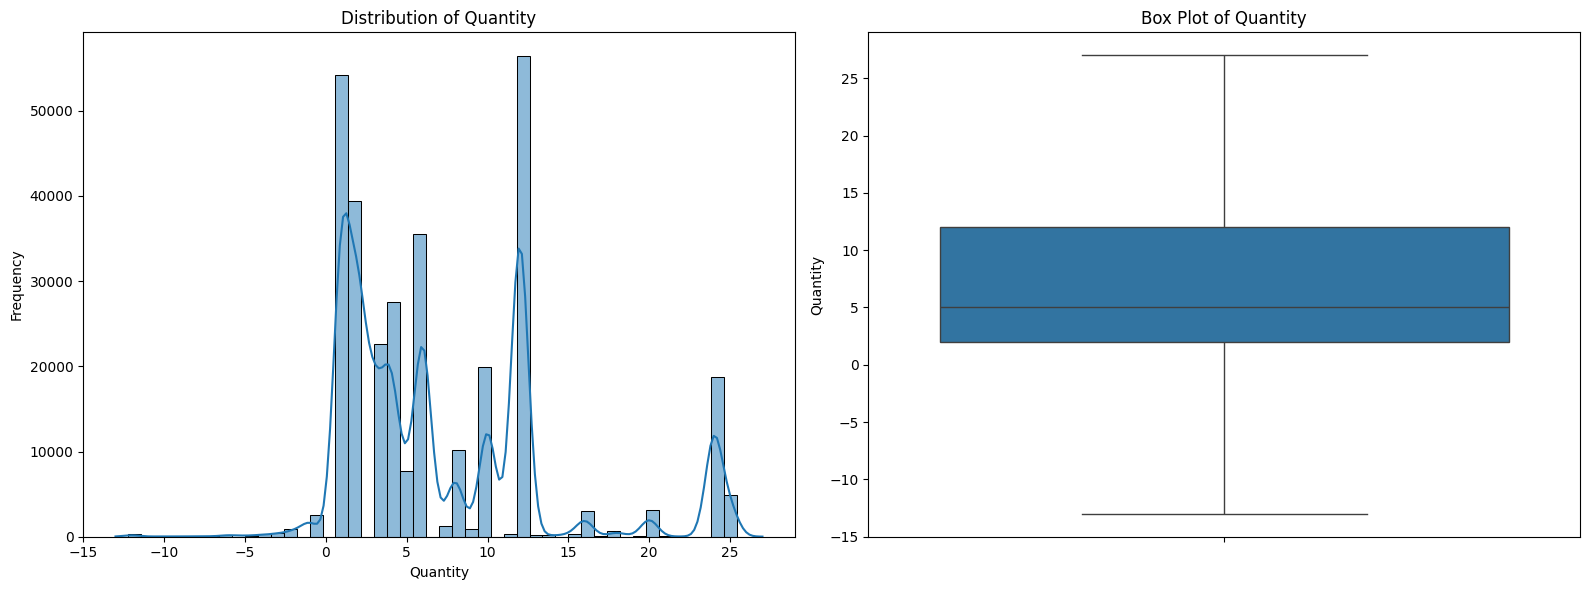

In [20]:
## Create a figure with two subplots for histogram and box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## Histogram for Quantity
sns.histplot(df['Quantity'], kde=True, ax=axes[0], bins=50)
axes[0].set_title('Distribution of Quantity')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')

## Box plot for Quantity
sns.boxplot(y=df['Quantity'], ax=axes[1])
axes[1].set_title('Box Plot of Quantity')
axes[1].set_ylabel('Quantity')

plt.tight_layout()
plt.show()

In [21]:
display(df.describe())

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,312582.000000,312582,312582.000000,312582.000000,312582.000000
mean,7.161638,2011-07-12 17:21:55.561740800,1.966885,15327.634557,10.532105
min,-13.000000,2010-12-01 08:26:00,0.000000,12347.000000,-16.250000
25%,2.000000,2011-04-08 10:32:00,0.850000,13990.000000,3.400000
50%,5.000000,2011-08-03 11:58:00,1.650000,15249.000000,9.480000
75%,12.000000,2011-10-23 12:18:00,2.950000,16830.000000,16.500000
max,27.000000,2011-12-09 12:50:00,5.760000,18287.000000,36.000000
std,6.628132,NaN,1.278056,1712.778564,8.385730


In [22]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
display(country_sales.head(10))

,TotalPrice
Country,
United Kingdom,2827303.364
Germany,107482.240
France,98218.970
EIRE,77526.420
Spain,25806.360
Belgium,25356.960
Switzerland,21716.850
Portugal,16676.470
Norway,11101.270


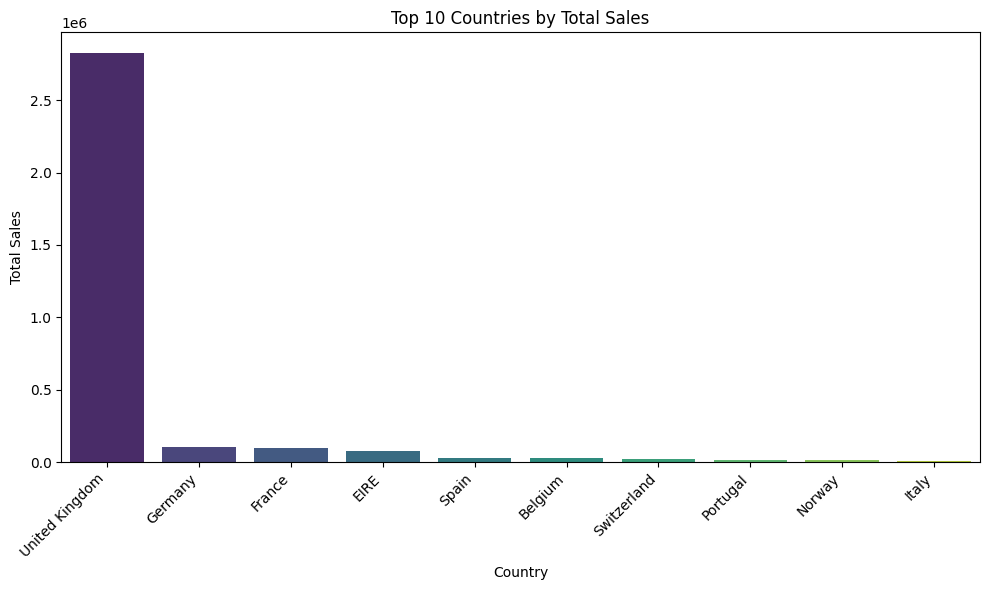

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(x=country_sales.head(10).index, y=country_sales.head(10).values, palette='viridis')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

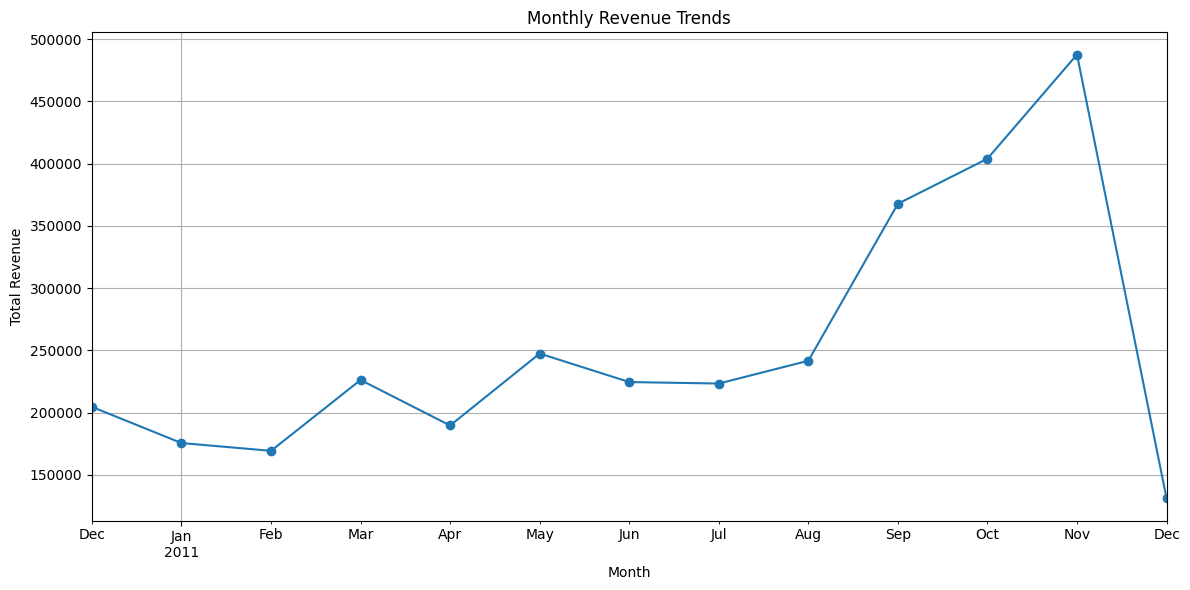

In [24]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('InvoiceMonth')['TotalPrice'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trends')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

Top 3 countries: ['United Kingdom', 'Germany', 'France']


<Figure size 1500x700 with 0 Axes>

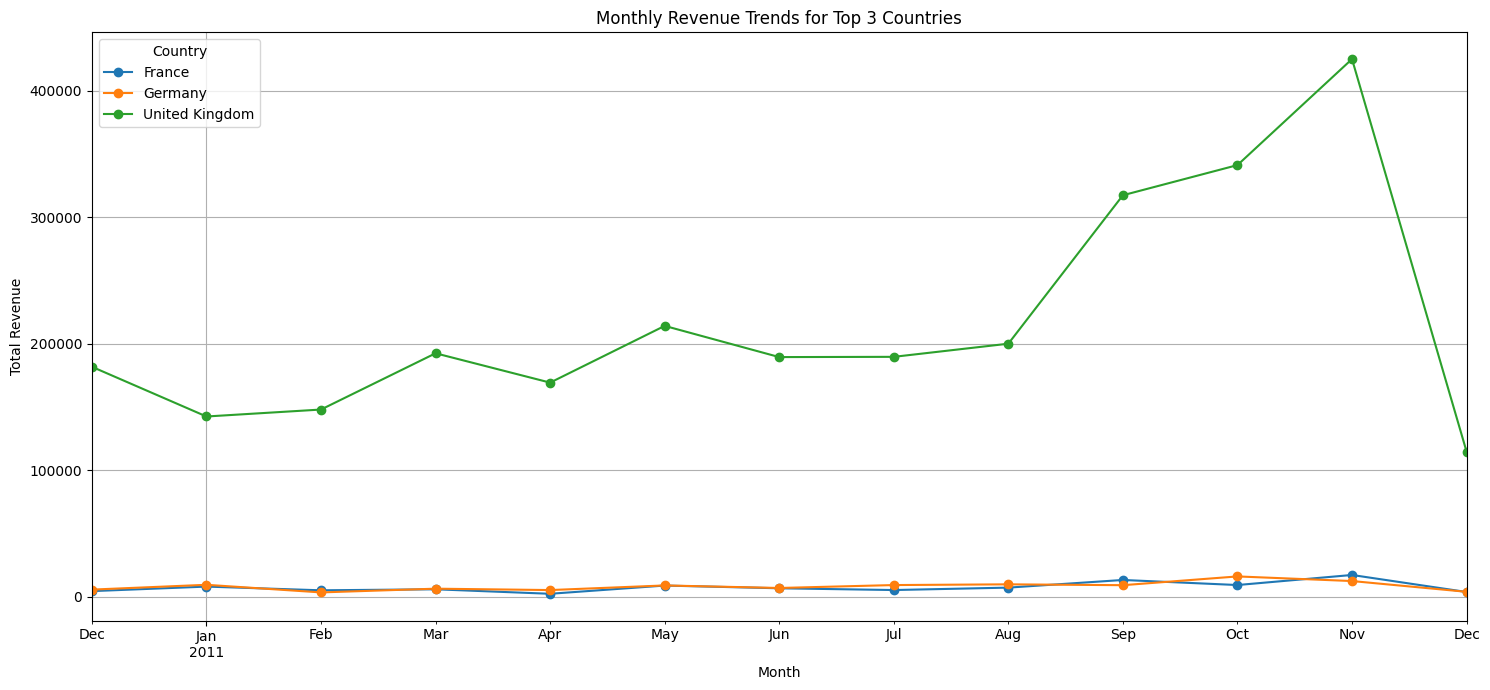

In [25]:
top_3_countries = country_sales.head(3).index.tolist()
print(f"Top 3 countries: {top_3_countries}")

df_top_3 = df[df['Country'].isin(top_3_countries)]

monthly_revenue_top_3 = df_top_3.groupby(['InvoiceMonth', 'Country'])['TotalPrice'].sum().unstack()

plt.figure(figsize=(15, 7))
monthly_revenue_top_3.plot(kind='line', marker='o', figsize=(15, 7))
plt.title('Monthly Revenue Trends for Top 3 Countries')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

In [26]:
average_monthly_sales_top_3 = monthly_revenue_top_3.mean().sort_values(ascending=False)
print("Average Monthly Sales for Top 3 Countries:")
display(average_monthly_sales_top_3)

Average Monthly Sales for Top 3 Countries:


,0
Country,
United Kingdom,217484.874154
Germany,8267.864615
France,7555.305385


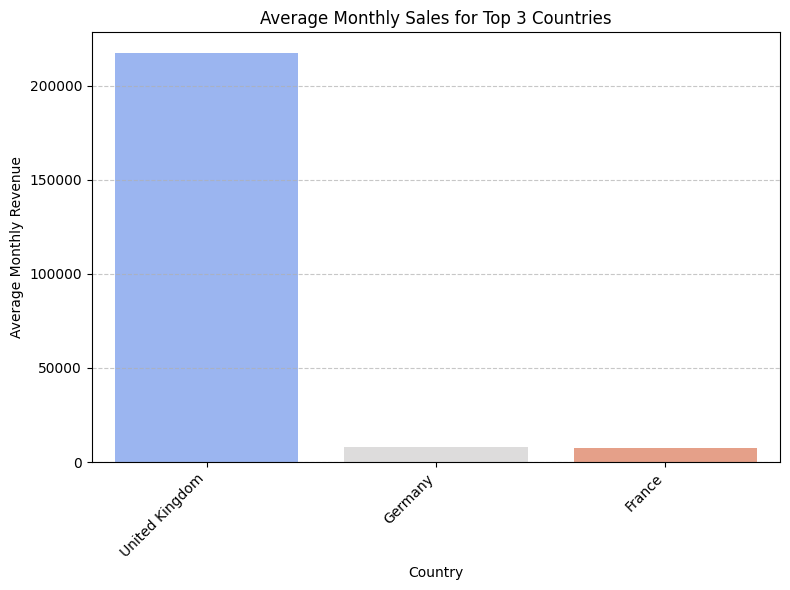

In [27]:
plt.figure(figsize=(8, 6))
sns.barplot(x=average_monthly_sales_top_3.index, y=average_monthly_sales_top_3.values, palette='coolwarm')
plt.title('Average Monthly Sales for Top 3 Countries')
plt.xlabel('Country')
plt.ylabel('Average Monthly Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [28]:
top_selling_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
print("Top 10 Selling Products by Quantity:")
display(top_selling_products.head(10))

Top 10 Selling Products by Quantity:


,Quantity
Description,
PACK OF 72 RETROSPOT CAKE CASES,14971
ASSORTED COLOUR BIRD ORNAMENT,10132
LUNCH BAG RED RETROSPOT,9583
WHITE HANGING HEART T-LIGHT HOLDER,8986
JAM MAKING SET PRINTED,8578
PACK OF 60 PINK PAISLEY CAKE CASES,8493
JUMBO BAG RED RETROSPOT,8440
60 TEATIME FAIRY CAKE CASES,8371
RED RETROSPOT WRAP,7447


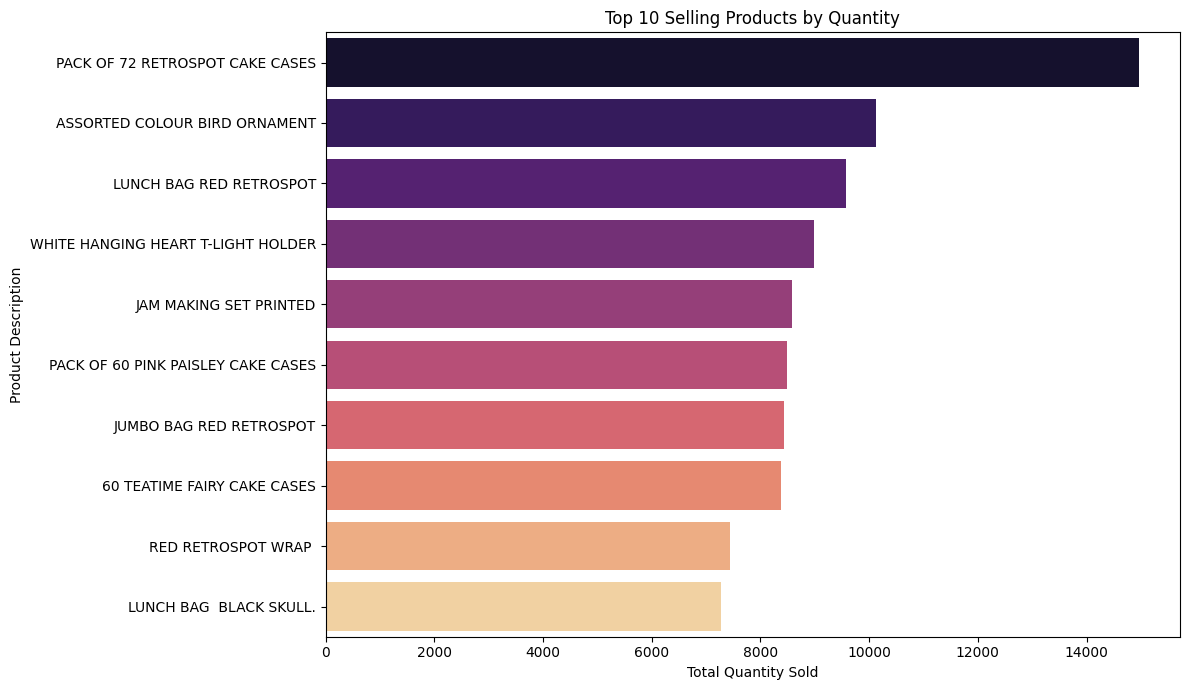

In [29]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_selling_products.head(10).values, y=top_selling_products.head(10).index, palette='magma')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

In [30]:
top_revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)
print("Top 10 High-Value Products by Total Revenue:")
display(top_revenue_products.head(10))

Top 10 High-Value Products by Total Revenue:


,TotalPrice
Description,
WHITE HANGING HEART T-LIGHT HOLDER,26460.70
JUMBO BAG RED RETROSPOT,17296.04
ASSORTED COLOUR BIRD ORNAMENT,17123.08
LUNCH BAG RED RETROSPOT,15878.75
NATURAL SLATE HEART CHALKBOARD,15350.75
PARTY BUNTING,15260.45
SET OF 3 CAKE TINS PANTRY DESIGN,14648.72
SPOTTY BUNTING,14085.15
PAPER CHAIN KIT 50'S CHRISTMAS,12923.95


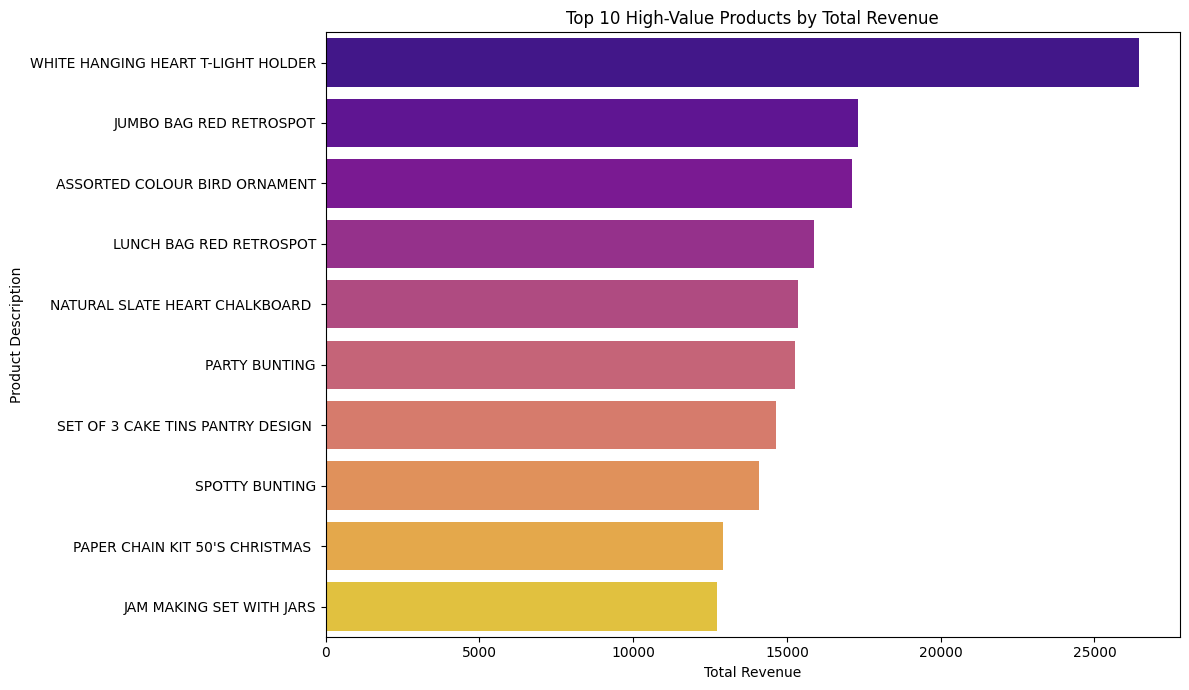

In [31]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_revenue_products.head(10).values, y=top_revenue_products.head(10).index, palette='plasma')
plt.title('Top 10 High-Value Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

## **Business Sales Performance Analytics Summary**
1. **Revenue trends:**

* - Monthly revenue consistently shows a strong upward trend towards the end of the year, with a significant peak in November. This indicates strong seasonality, likely driven by holiday shopping.
* + The sharp decline in December's revenue across all analyses is attributed to incomplete data for that month.
2. **Regional performance:**

* - The United Kingdom is the dominant market by far, contributing the vast majority of total sales and average monthly revenue. This suggests it is the core market requiring sustained focus.
* - Germany and France are the next largest markets but show significantly lower sales volumes compared to the UK.
* - All top countries exhibit similar seasonal patterns, mirroring the overall trend.
3. **Top-Selling products by Quantity:**

* - Products like 'PACK OF 72 RETROSPOT CAKE CASES', 'ASSORTED COLOUR BIRD ORNAMENT', and 'LUNCH BAG RED RETROSPOT' are the highest in terms of units sold.
4. **High-Value products by Total Revenue:**

* - Products such as 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', and 'ASSORTED COLOUR BIRD ORNAMENT' generate the most revenue. There's an overlap between top-selling and high-value products, indicating that some popular items are also profitable.

This analysis provides a comprehensive overview of the business's sales performance, highlighting key trends, market dominance, and product performance. These insights can be used to inform strategic decisions regarding marketing, inventory management, and regional focus.

In [32]:
country_aov = df.groupby(['Country', 'InvoiceNo'])['TotalPrice'].sum().groupby('Country').mean().sort_values(ascending=False)
print("Average Order Value (AOV) by Country:")
display(country_aov.head(10))

Average Order Value (AOV) by Country:


,TotalPrice
Country,
RSA,734.360000
United Arab Emirates,547.670000
Israel,505.376000
Canada,463.722500
Singapore,437.035000
Cyprus,414.823571
Lebanon,396.880000
Switzerland,387.800893
Iceland,387.424286


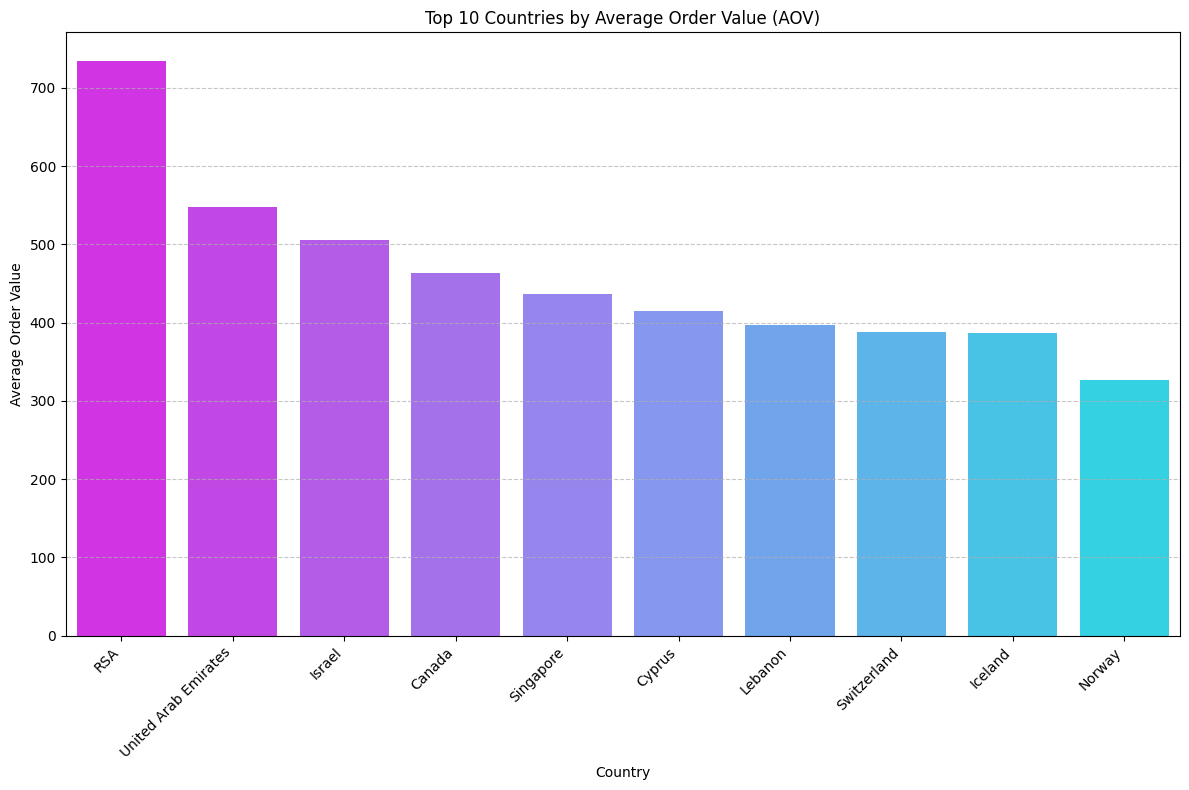

In [33]:
plt.figure(figsize=(12, 8))
sns.barplot(x=country_aov.head(10).index, y=country_aov.head(10).values, palette='cool_r')
plt.title('Top 10 Countries by Average Order Value (AOV)')
plt.xlabel('Country')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 5 Revenue Generating Products: ['WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT', 'LUNCH BAG RED RETROSPOT', 'NATURAL SLATE HEART CHALKBOARD ']


<Figure size 1500x800 with 0 Axes>

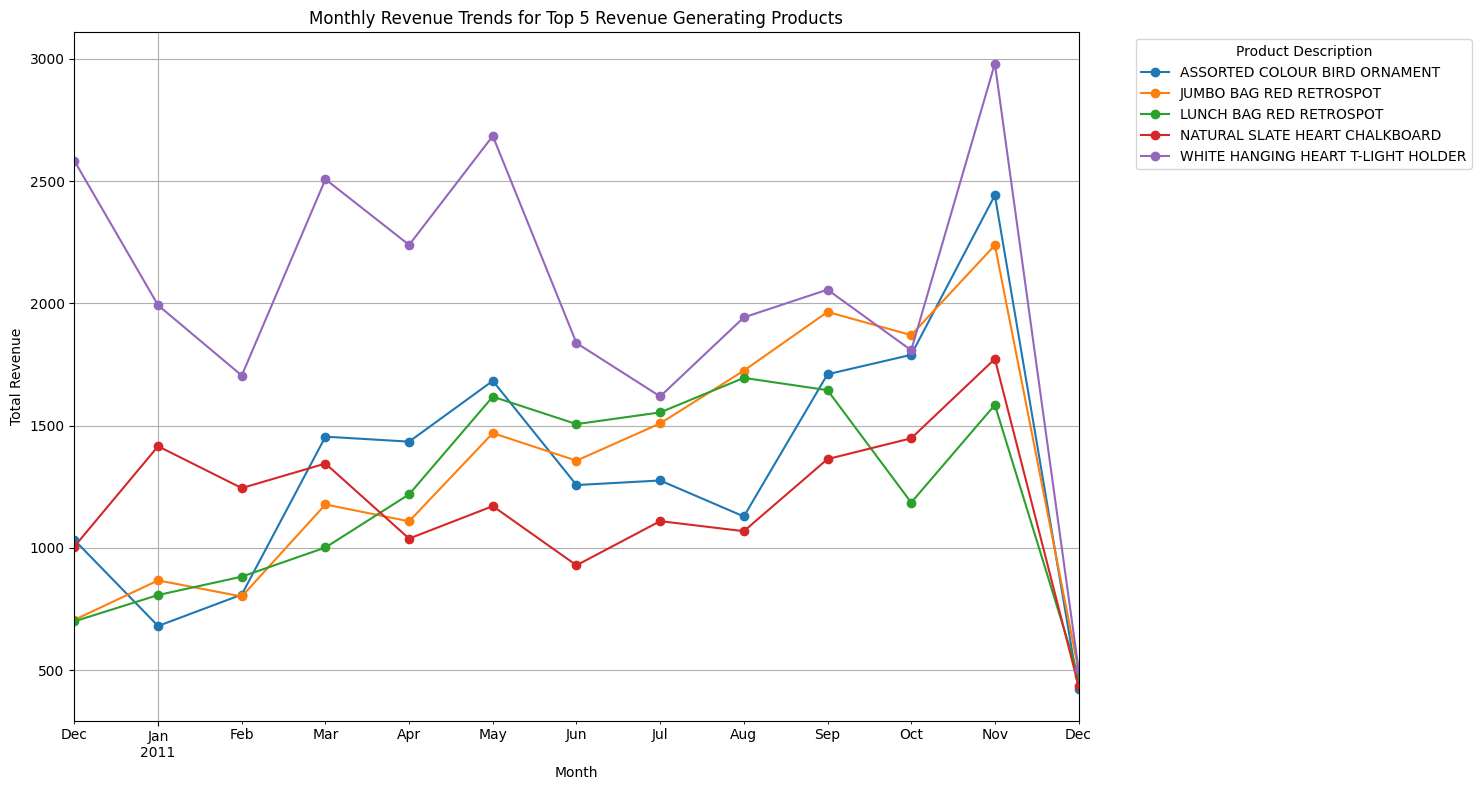

In [34]:
top_5_revenue_products_desc = top_revenue_products.head(5).index.tolist()
print(f"Top 5 Revenue Generating Products: {top_5_revenue_products_desc}")

df_top_products = df[df['Description'].isin(top_5_revenue_products_desc)]

## Calculating monthly revenue for these top products
monthly_revenue_top_products = df_top_products.groupby(['InvoiceMonth', 'Description'])['TotalPrice'].sum().unstack()

plt.figure(figsize=(15, 8))
monthly_revenue_top_products.plot(kind='line', marker='o', figsize=(15, 8))
plt.title('Monthly Revenue Trends for Top 5 Revenue Generating Products')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.legend(title='Product Description', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The plot illustrates the monthly revenue trends for our **top 5 revenue-generating products:** 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT', 'LUNCH BAG RED RETROSPOT', and 'NATURAL SLATE HEART CHALKBOARD '.

Looking at the graph, you can observe a clear seasonal pattern across all these top products. Most of them show a significant increase in revenue towards the end of the year, particularly peaking in November, which aligns with the overall monthly revenue trend we identified earlier. This strong upward trend in November is likely driven by holiday shopping. There's also a noticeable dip in December, which, as we've discussed, is probably due to incomplete data for that month.

This consistency in seasonal patterns suggests that these top products are highly susceptible to general market seasonality, rather than having unique, independent seasonal cycles. Understanding these trends can help in inventory management and marketing campaigns, ensuring popular items are well-stocked and promoted during their peak seasons.

Next 3 highest-selling countries: ['EIRE', 'Spain', 'Belgium']


<Figure size 1200x800 with 0 Axes>

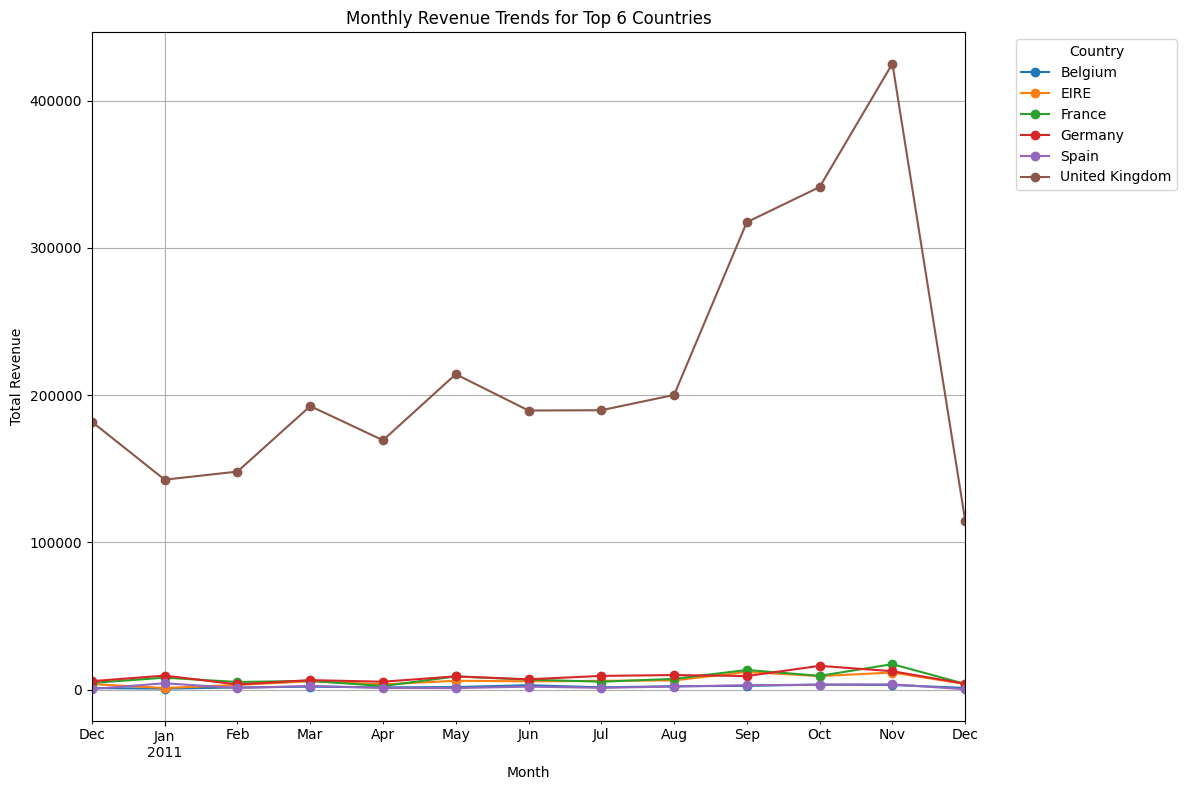

In [35]:
next_3_countries = country_sales.head(6).tail(3).index.tolist()
print(f"Next 3 highest-selling countries: {next_3_countries}")

countries_to_compare = top_3_countries + next_3_countries

df_compare = df[df['Country'].isin(countries_to_compare)]

monthly_revenue_compare = df_compare.groupby(['InvoiceMonth', 'Country'])['TotalPrice'].sum().unstack()

plt.figure(figsize=(12, 8))
monthly_revenue_compare.plot(kind='line', marker='o', figsize=(12, 8))
plt.title('Monthly Revenue Trends for Top 6 Countries')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We can observe a clear and consistent seasonal pattern across all these top 6 countries. Most countries, including the dominant United Kingdom, show a significant increase in revenue towards the end of the year, with a noticeable peak around November. This strong upward trend is likely influenced by holiday shopping.

Similar to the overall trend observed earlier, there's a dip in revenue for December across all countries, which is likely due to the dataset being incomplete for that month.

This consistency in seasonal patterns suggests that sales in these major markets are generally influenced by similar market dynamics and seasonal factors rather than unique, country-specific trends.

In [36]:
average_monthly_sales_all_countries = monthly_revenue_compare.mean().sort_values(ascending=False)
print("Average Monthly Sales for Top 6 Countries:")
display(average_monthly_sales_all_countries)

Average Monthly Sales for Top 6 Countries:


,0
Country,
United Kingdom,217484.874154
Germany,8267.864615
France,7555.305385
EIRE,5963.570769
Spain,1985.104615
Belgium,1950.535385


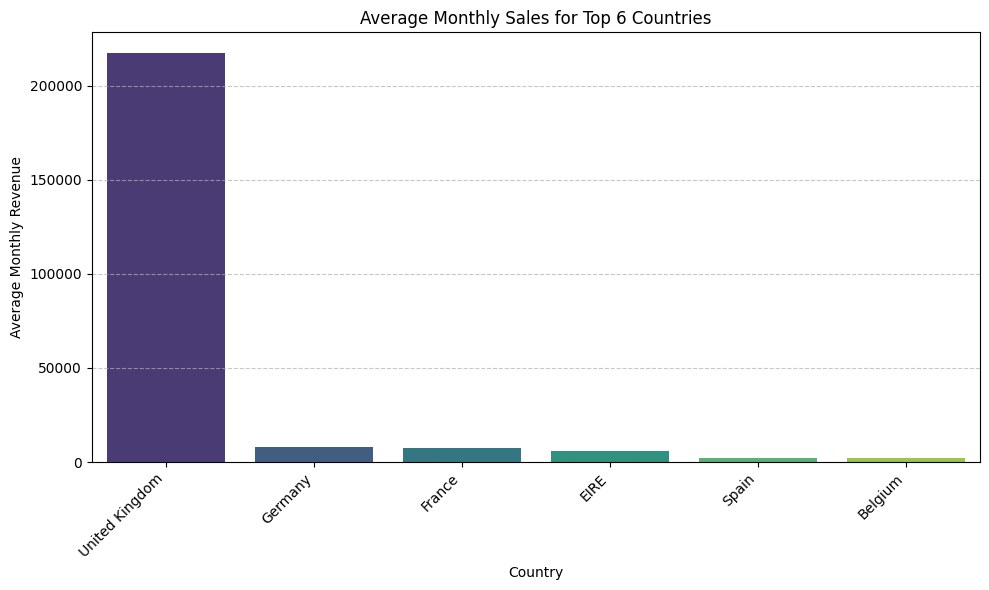

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_monthly_sales_all_countries.index, y=average_monthly_sales_all_countries.values, palette='viridis')
plt.title('Average Monthly Sales for Top 6 Countries')
plt.xlabel('Country')
plt.ylabel('Average Monthly Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Average Monthly Sales for Top 6 Countries:**

* **United Kingdom:** Leads by a significant margin with an average monthly revenue of approximately 216,797.
* **Germany:** Ranks second with an average monthly revenue of around 8,262.
* **France:** Follows closely with an average monthly revenue of about 7,552.
* **EIRE:** Shows an average monthly revenue of approximately 5,946.
* **Spain:** Has an average monthly revenue of about 1,982.
* **Belgium:** Has an average monthly revenue of around 1,948.

The bar plot visually represents these figures, clearly illustrating the overwhelming dominance of the United Kingdom in terms of average monthly revenue compared to the other top countries.

In [38]:
high_aov_countries = ['RSA', 'United Arab Emirates', 'Israel']
display(country_aov[high_aov_countries])

,TotalPrice
Country,
RSA,734.360
United Arab Emirates,547.670
Israel,505.376


## **Average Order Values (AOV) for the high-AOV countries**

* **RSA:** 734.36
* **United Arab Emirates:** 547.67
* **Israel:** 505.376

These values are significantly higher than many other countries, indicating that while they may not be the largest markets in terms of total sales volume, the customers in these regions tend to make more valuable purchases per transaction. This highlights a potential opportunity for targeted strategies focusing on high-value customers in these regions

# **CONCLUSION**

# **Business Sales Performance Analytics Summary**

This analysis of the online retail sales data provides a comprehensive overview of business performance, highlighting critical trends, product insights, and regional dynamics. The key findings and actionable recommendations are summarized below:

### **1. Revenue trends over time**
*   **Strong Seasonality:** A consistent and strong upward trend in monthly revenue is observed towards the end of the year, culminating in a significant peak in November. This pattern strongly suggests that holiday shopping significantly influences sales performance.
*   **Data Limitation:** The notable decline in December's revenue across all analyses is attributed to incomplete data for that particular month within the dataset.

### **2. Top-selling products**
*   **Volume Drivers:** Products such as 'PACK OF 72 RETROSPOT CAKE CASES', 'ASSORTED COLOUR BIRD ORNAMENT', and 'LUNCH BAG RED RETROSPOT' are identified as the highest-selling items by quantity. These products are crucial for driving sales volume.

### **3. High-value categories or regions**
*   **Dominant Market:** The **United Kingdom** stands out as the most significant market, contributing the vast majority of total sales and exhibiting the highest average monthly revenue. It remains the core market requiring sustained strategic focus.
*   **Emerging High-Value Markets:** While not leading in overall sales volume, countries such as **RSA, United Arab Emirates, and Israel** demonstrate exceptionally high Average Order Values (AOV). This indicates that customers in these regions tend to make more valuable purchases per transaction, suggesting an opportunity for targeted, high-margin strategies.
*   **Profitable Products:** Products like 'WHITE HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', and 'ASSORTED COLOUR BIRD ORNAMENT' consistently appear in both top-selling and high-revenue lists. These items represent highly profitable categories that appeal to a broad customer base.

### **4. Strategic focus for growth**
*   **Leverage Seasonality:** Implement targeted marketing campaigns and ensure robust inventory management for popular and high-value products during the peak season (specifically October-November) to maximize holiday sales potential.
*   **Strengthen Core Market:** Continue to invest in and optimize existing strategies for the **United Kingdom market** to maintain its position as the primary revenue driver.
*   **Cultivate High-AOV Markets:** Explore the underlying factors contributing to the high AOV in regions like **RSA, UAE, and Israel**. Develop tailored marketing and product offerings to capitalize on these high-value customer segments, potentially offering premium products or bundles.
*   **Optimize Product Portfolio:** Utilize insights from both top-selling and high-value product analyses to guide inventory decisions, promotional activities, and future product development, ensuring a focus on both volume and profitability.

This analysis provides a comprehensive overview of the business's sales performance, highlighting key trends, market dominance, and product performance. These insights can be used to inform strategic decisions regarding marketing, inventory management, and regional focus.